In [ ]:
# Basic setup
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import joblib


In [36]:
df = pd.read_csv("/content/services-2025-10.csv")

print("Shape:", df.shape)
display(df.head(5))
df.info()


Shape: (1952924, 20)


,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform
0,16888633,2025-10-01,Nightjet,NS Int,420,False,False,69,152770640,NURNB,Nürnberg Hbf,NaN,NaN,NaN,2025-10-01T02:01:00+02:00,0.0,False,False,NaN,NaN
1,16888633,2025-10-01,Nightjet,NS Int,420,False,False,1,152770641,WURZB,Würzburg Hbf,2025-10-01T02:30:00+02:00,0.0,False,2025-10-01T02:32:00+02:00,0.0,False,False,NaN,NaN
2,16888633,2025-10-01,Nightjet,NS Int,420,False,False,0,152770642,FFFM,Frankfurt (M) Hbf,2025-10-01T04:55:00+02:00,0.0,False,2025-10-01T05:00:00+02:00,0.0,False,False,NaN,NaN
3,16888633,2025-10-01,Nightjet,NS Int,420,False,False,0,152770643,HAMM,Hamm (Westf.),2025-10-01T06:28:00+02:00,0.0,False,2025-10-01T06:30:00+02:00,0.0,False,False,NaN,NaN
4,16888633,2025-10-01,Nightjet,NS Int,420,False,False,0,152770644,MUNST,Münster (Westf) Hbf,2025-10-01T06:51:00+02:00,0.0,False,2025-10-01T07:54:00+02:00,0.0,False,False,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1952924 entries, 0 to 1952923
Data columns (total 20 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Service:RDT-ID                int64  
 1   Service:Date                  object 
 2   Service:Type                  object 
 3   Service:Company               object 
 4   Service:Train number          int64  
 5   Service:Completely cancelled  bool   
 6   Service:Partly cancelled      bool   
 7   Service:Maximum delay         int64  
 8   Stop:RDT-ID                   int64  
 9   Stop:Station code             object 
 10  Stop:Station name             object 
 11  Stop:Arrival time             object 
 12  Stop:Arrival delay            float64
 13  Stop:Arrival cancelled        object 
 14  Stop:Departure time           object 
 15  Stop:Departure delay          float64
 16  Stop:Departure cancelled      object 
 17  Stop:Platform change          bool   
 18  Stop:Planned platform 

In [ ]:
# Make a copy (optional, but nice to keep original)
df_raw = df.copy()

# Clean column names: lower case, replace spaces and ':' with '_'
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
      .str.replace(':', '_')
)

df.columns


Index(['service_rdt-id', 'service_date', 'service_type', 'service_company',
       'service_train_number', 'service_completely_cancelled',
       'service_partly_cancelled', 'service_maximum_delay', 'stop_rdt-id',
       'stop_station_code', 'stop_station_name', 'stop_arrival_time',
       'stop_arrival_delay', 'stop_arrival_cancelled', 'stop_departure_time',
       'stop_departure_delay', 'stop_departure_cancelled',
       'stop_platform_change', 'stop_planned_platform',
       'stop_actual_platform'],
      dtype='object')

In [ ]:
# Convert service_date to datetime
df['service_date'] = pd.to_datetime(df['service_date'], errors='coerce')

# Convert arrival/departure times to datetime
for col in ['stop_arrival_time', 'stop_departure_time']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Quick check
df[['service_date', 'stop_arrival_time', 'stop_departure_time']].head()


/tmp/ipython-input-2229952736.py:6: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df[col] = pd.to_datetime(df[col], errors='coerce')


,service_date,stop_arrival_time,stop_departure_time
0,2025-10-01,NaT,2025-10-01 02:01:00+02:00
1,2025-10-01,2025-10-01 02:30:00+02:00,2025-10-01 02:32:00+02:00
2,2025-10-01,2025-10-01 04:55:00+02:00,2025-10-01 05:00:00+02:00
3,2025-10-01,2025-10-01 06:28:00+02:00,2025-10-01 06:30:00+02:00
4,2025-10-01,2025-10-01 06:51:00+02:00,2025-10-01 07:54:00+02:00


In [ ]:
# Basic stats of arrival delay
df['stop_arrival_delay'].describe()


,stop_arrival_delay
count,859676.000000
mean,1.002905
std,3.451415
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,286.000000


In [ ]:
df['stop_arrival_cancelled'].value_counts(dropna=False)


,count
stop_arrival_cancelled,
False,821732
NaN,109265
True,37944


In [ ]:
df_model = df.copy()

df_model = df_model[df_model['stop_arrival_time'].notna()]
df_model = df_model[df_model['stop_arrival_cancelled'] != True]
df_model = df_model[df_model['stop_arrival_delay'].notna()]



In [ ]:
df_model = df.copy()

# Keep only rows with arrival time
df_model = df_model[df_model['stop_arrival_time'].notna()]

# Remove cancelled arrivals
df_model = df_model[df_model['stop_arrival_cancelled'] != True]

# Remove missing arrival delay
df_model = df_model[df_model['stop_arrival_delay'].notna()]

print("df_model created with rows:", df_model.shape)


df_model created with rows: (821732, 20)


In [ ]:
df_model['arr_hour'] = df_model['stop_arrival_time'].dt.hour
df_model['arr_dayofweek'] = df_model['stop_arrival_time'].dt.dayofweek
df_model['arr_month'] = df_model['stop_arrival_time'].dt.month
df_model['is_weekend'] = df_model['arr_dayofweek'].isin([5,6]).astype(int)


In [ ]:
print("===== BASIC INFO =====")
print(df_model.info(), "\n")

print("===== SHAPE =====")
print("Rows:", df_model.shape[0], " Columns:", df_model.shape[1], "\n")

# -------------------------
# 1. Missing Value Summary
# -------------------------
print("===== MISSING VALUES (%) =====")
missing_percent = df_model.isna().mean() * 100
print(missing_percent.sort_values(ascending=False), "\n")

# -------------------------
# 2. Duplicate Rows
# -------------------------
print("===== DUPLICATES =====")
print("Number of duplicate rows:", df_model.duplicated().sum(), "\n")

# -------------------------
# 3. Target Column Check
# -------------------------
print("===== TARGET COLUMN CHECK =====")
print("Missing target values:", df_model['stop_arrival_delay'].isna().sum())
print(df_model['stop_arrival_delay'].describe(), "\n")

# -------------------------
# 4. Cancelled Stops Check
# -------------------------
if 'stop_arrival_cancelled' in df_model.columns:
    print("===== CANCELLED ARRIVAL CHECK =====")
    print(df_model['stop_arrival_cancelled'].value_counts(dropna=False), "\n")

# -------------------------
# 5. Datetime Validity Check
# -------------------------
print("===== DATETIME CHECK =====")
print("Arrival time missing:", df_model['stop_arrival_time'].isna().sum())
print("Departure time missing:", df_model['stop_departure_time'].isna().sum(), "\n")

# -------------------------
# 6. Outlier Analysis for Delay
# -------------------------
print("===== OUTLIER CHECK (stop_arrival_delay) =====")
q1 = df_model['stop_arrival_delay'].quantile(0.25)
q3 = df_model['stop_arrival_delay'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr
outliers = df_model[(df_model['stop_arrival_delay'] > upper_bound)]
print("Upper bound:", upper_bound)
print("Outliers above upper bound:", outliers.shape[0])
print("Max delay:", df_model['stop_arrival_delay'].max(), "\n")

# -------------------------
# 7. Mixed Type Columns Check
# -------------------------
print("===== MIXED DATA TYPES CHECK =====")
mixed_type_cols = []
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        unique_dtypes = df_model[col].apply(type).nunique()
        if unique_dtypes > 1:
            mixed_type_cols.append(col)

print("Columns with mixed types:", mixed_type_cols, "\n")

# -------------------------
# 8. Sample Output
# -------------------------
print("===== SAMPLE ROWS (HEAD) =====")
display(df_model.head())

print("===== SAMPLE ROWS (TAIL) =====")
display(df_model.tail())


===== BASIC INFO =====
<class 'pandas.core.frame.DataFrame'>
Index: 821732 entries, 1 to 968938
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype                    
---  ------                        --------------   -----                    
 0   service_rdt-id                821732 non-null  int64                    
 1   service_date                  821732 non-null  datetime64[ns]           
 2   service_type                  821732 non-null  object                   
 3   service_company               821732 non-null  object                   
 4   service_train_number          821732 non-null  int64                    
 5   service_completely_cancelled  821732 non-null  bool                     
 6   service_partly_cancelled      821732 non-null  bool                     
 7   service_maximum_delay         821732 non-null  int64                    
 8   stop_rdt-id                   821732 non-null  int64                    
 9   stop_sta

,service_rdt-id,service_date,service_type,service_company,service_train_number,service_completely_cancelled,service_partly_cancelled,service_maximum_delay,stop_rdt-id,stop_station_code,...,stop_departure_time,stop_departure_delay,stop_departure_cancelled,stop_platform_change,stop_planned_platform,stop_actual_platform,arr_hour,arr_dayofweek,arr_month,is_weekend
1,16888633,2025-10-01,Nightjet,NS Int,420,False,False,1,152770641,WURZB,...,2025-10-01 02:32:00+02:00,0.0,False,False,NaN,NaN,2,2,10,0
2,16888633,2025-10-01,Nightjet,NS Int,420,False,False,0,152770642,FFFM,...,2025-10-01 05:00:00+02:00,0.0,False,False,NaN,NaN,4,2,10,0
3,16888633,2025-10-01,Nightjet,NS Int,420,False,False,0,152770643,HAMM,...,2025-10-01 06:30:00+02:00,0.0,False,False,NaN,NaN,6,2,10,0
4,16888633,2025-10-01,Nightjet,NS Int,420,False,False,0,152770644,MUNST,...,2025-10-01 07:54:00+02:00,0.0,False,False,NaN,NaN,6,2,10,0
5,16888633,2025-10-01,Nightjet,NS Int,420,False,False,0,152770645,RHEINE,...,2025-10-01 08:19:00+02:00,54.0,False,False,NaN,NaN,8,2,10,0


===== SAMPLE ROWS (TAIL) =====


,service_rdt-id,service_date,service_type,service_company,service_train_number,service_completely_cancelled,service_partly_cancelled,service_maximum_delay,stop_rdt-id,stop_station_code,...,stop_departure_time,stop_departure_delay,stop_departure_cancelled,stop_platform_change,stop_planned_platform,stop_actual_platform,arr_hour,arr_dayofweek,arr_month,is_weekend
968933,16998085,2025-10-16,Sprinter,NS,8955,False,False,0,153743665,UTLR,...,2025-10-16 15:26:00+02:00,0.0,False,False,1,1,15,3,10,0
968934,16998085,2025-10-16,Sprinter,NS,8955,False,False,0,153743666,UT,...,NaT,NaN,NaN,False,20,20,15,3,10,0
968936,16998086,2025-10-16,Intercity,NS,1152,False,True,0,153743668,TB,...,2025-10-16 15:37:00+02:00,0.0,False,False,2,2,15,3,10,0
968937,16998086,2025-10-16,Intercity,NS,1152,False,True,0,153743669,BD,...,2025-10-16 15:53:00+02:00,0.0,False,False,7,7,15,3,10,0
968938,16998086,2025-10-16,Intercity,NS,1152,False,True,0,153743670,RTD,...,2025-10-16 16:18:00+02:00,0.0,True,True,13,9,16,3,10,0


In [ ]:
# STEP 1: Define target and feature columns

# 1) Target column (what we want to predict)
target = 'stop_arrival_delay'

# 2) Feature columns (inputs to the model)
features = [
    # numeric operational
    'service_train_number',
    'service_maximum_delay',

    # numeric time-based
    'arr_hour',
    'arr_dayofweek',
    'arr_month',
    'is_weekend',

    # categorical
    'service_type',
    'service_company',
    'stop_station_code',
    'stop_platform_change',
    'stop_planned_platform',
    'stop_actual_platform'
]

# Keep only columns that actually exist in df_model
features = [f for f in features if f in df_model.columns]

print("✅ Features being used ({}):".format(len(features)))
print(features)

print("\n🔍 Preview of these feature columns:")
display(df_model[features].head())

print("\n❓ Missing values fraction in each feature:")
display(df_model[features].isna().mean())


✅ Features being used (12):
['service_train_number', 'service_maximum_delay', 'arr_hour', 'arr_dayofweek', 'arr_month', 'is_weekend', 'service_type', 'service_company', 'stop_station_code', 'stop_platform_change', 'stop_planned_platform', 'stop_actual_platform']

🔍 Preview of these feature columns:


,service_train_number,service_maximum_delay,arr_hour,arr_dayofweek,arr_month,is_weekend,service_type,service_company,stop_station_code,stop_platform_change,stop_planned_platform,stop_actual_platform
1,420,1,2,2,10,0,Nightjet,NS Int,WURZB,False,NaN,NaN
2,420,0,4,2,10,0,Nightjet,NS Int,FFFM,False,NaN,NaN
3,420,0,6,2,10,0,Nightjet,NS Int,HAMM,False,NaN,NaN
4,420,0,6,2,10,0,Nightjet,NS Int,MUNST,False,NaN,NaN
5,420,0,8,2,10,0,Nightjet,NS Int,RHEINE,False,NaN,NaN



❓ Missing values fraction in each feature:


,0
service_train_number,0.000000
service_maximum_delay,0.000000
arr_hour,0.000000
arr_dayofweek,0.000000
arr_month,0.000000
is_weekend,0.000000
service_type,0.000000
service_company,0.000000
stop_station_code,0.001379
stop_platform_change,0.000000


In [ ]:
# STEP 2: Time-based train/test split

# 1) Sort by arrival time to respect time order
df_model = df_model.sort_values(by='stop_arrival_time')

# 2) Compute split index (80% train, 20% test)
split_idx = int(len(df_model) * 0.8)

# 3) Create train and test dataframes
train_df = df_model.iloc[:split_idx]
test_df  = df_model.iloc[split_idx:]

# 4) Split into X (features) and y (target)
X_train = train_df[features]
y_train = train_df[target]

X_test  = test_df[features]
y_test  = test_df[target]

print("✅ Train shape:", X_train.shape, " Target shape:", y_train.shape)
print("✅ Test  shape:", X_test.shape,  " Target shape:", y_test.shape)

print("\n🔍 Train time range:")
print(train_df['stop_arrival_time'].min(), "→", train_df['stop_arrival_time'].max())

print("\n🔍 Test time range:")
print(test_df['stop_arrival_time'].min(), "→", test_df['stop_arrival_time'].max())


✅ Train shape: (657385, 12)  Target shape: (657385,)
✅ Test  shape: (164347, 12)  Target shape: (164347,)

🔍 Train time range:
2025-10-01 02:14:00+02:00 → 2025-10-13 16:41:00+02:00

🔍 Test time range:
2025-10-13 16:41:00+02:00 → 2025-10-16 20:20:00+02:00


In [ ]:
# STEP 3: Preprocessing pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify numeric and categorical features
numeric_features = [
    'service_train_number',
    'service_maximum_delay',
    'arr_hour',
    'arr_dayofweek',
    'arr_month',
    'is_weekend'
]

categorical_features = [
    'service_type',
    'service_company',
    'stop_station_code',
    'stop_platform_change',
    'stop_planned_platform',
    'stop_actual_platform'
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into one transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("\n✅ Preprocessing pipeline created successfully!")


Numeric features: ['service_train_number', 'service_maximum_delay', 'arr_hour', 'arr_dayofweek', 'arr_month', 'is_weekend']
Categorical features: ['service_type', 'service_company', 'stop_station_code', 'stop_platform_change', 'stop_planned_platform', 'stop_actual_platform']

✅ Preprocessing pipeline created successfully!


In [ ]:
# STEP 4: Install XGBoost (run once)
!pip install xgboost

from xgboost import XGBRegressor
print("✅ XGBoost imported successfully!")


✅ XGBoost imported successfully!


In [ ]:
# STEP 5: Build XGBoost pipeline and train

# Define XGBoost regressor with reasonable starting hyperparameters
xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Full pipeline: preprocessing + model
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

print("⏳ Training XGBoost model...")
xgb_pipeline.fit(X_train, y_train)
print("✅ Training complete!")


⏳ Training XGBoost model...
✅ Training complete!


In [ ]:
# STEP 6 (FIXED): Evaluate XGBoost model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on test set
y_pred_xgb = xgb_pipeline.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred_xgb)

# RMSE manually:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

r2 = r2_score(y_test, y_pred_xgb)

print("📊 XGBoost Performance on Test Set")
print("----------------------------------")
print(f"MAE  (Mean Absolute Error): {mae:.3f} minutes")
print(f"RMSE (Root Mean Squared Error): {rmse:.3f} minutes")
print(f"R²   (R-squared): {r2:.3f}")

# Optional: sanity check
print("\n🔎 Actual vs Predicted (first 10 rows):")
comparison_df = pd.DataFrame({
    'actual_delay': y_test.values[:10],
    'predicted_delay': y_pred_xgb[:10]
})
display(comparison_df)


📊 XGBoost Performance on Test Set
----------------------------------
MAE  (Mean Absolute Error): 1.298 minutes
RMSE (Root Mean Squared Error): 3.340 minutes
R²   (R-squared): 0.061

🔎 Actual vs Predicted (first 10 rows):


,actual_delay,predicted_delay
0,0.0,3.083195
1,0.0,0.409936
2,0.0,0.356464
3,0.0,0.577758
4,0.0,0.773212
5,0.0,0.706041
6,2.0,0.529171
7,0.0,0.577758
8,0.0,0.635512
9,1.0,0.724942


In [ ]:
df_model.columns


Index(['service_rdt-id', 'service_date', 'service_type', 'service_company',
       'service_train_number', 'service_completely_cancelled',
       'service_partly_cancelled', 'service_maximum_delay', 'stop_rdt-id',
       'stop_station_code', 'stop_station_name', 'stop_arrival_time',
       'stop_arrival_delay', 'stop_arrival_cancelled', 'stop_departure_time',
       'stop_departure_delay', 'stop_departure_cancelled',
       'stop_platform_change', 'stop_planned_platform', 'stop_actual_platform',
       'arr_hour', 'arr_dayofweek', 'arr_month', 'is_weekend'],
      dtype='object')

In [ ]:
# STEP A: Create stop order (sequence of stops inside each service)
df_model = df_model.sort_values(by=['service_rdt-id', 'stop_arrival_time'])

df_model['stop_order'] = df_model.groupby('service_rdt-id').cumcount()

# STEP B: Create previous stop delay
df_model['prev_stop_delay'] = df_model.groupby('service_rdt-id')['stop_arrival_delay'].shift(1)

# Fill NaN for first stop of each service
df_model['prev_stop_delay'] = df_model['prev_stop_delay'].fillna(0)

print("Sample:")
df_model[['service_rdt-id', 'stop_order', 'stop_arrival_delay', 'prev_stop_delay']].head(10)


Sample:


,service_rdt-id,stop_order,stop_arrival_delay,prev_stop_delay
1,16888633,0,0.0,0.0
2,16888633,1,0.0,0.0
3,16888633,2,0.0,0.0
4,16888633,3,0.0,0.0
5,16888633,4,54.0,0.0
6,16888633,5,55.0,54.0
7,16888633,6,53.0,55.0
8,16888633,7,69.0,53.0
9,16888633,8,63.0,69.0
10,16888633,9,66.0,63.0


In [ ]:
features += ['stop_order', 'prev_stop_delay']


In [ ]:
print("Updated features:", features)

Updated features: ['service_train_number', 'service_maximum_delay', 'arr_hour', 'arr_dayofweek', 'arr_month', 'is_weekend', 'service_type', 'service_company', 'stop_station_code', 'stop_platform_change', 'stop_planned_platform', 'stop_actual_platform', 'stop_order', 'prev_stop_delay']


In [ ]:
# STEP C: Re-split train/test after adding new features

df_model = df_model.sort_values(by='stop_arrival_time')

split_idx = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_idx]
test_df  = df_model.iloc[split_idx:]

X_train = train_df[features]
y_train = train_df[target]

X_test  = test_df[features]
y_test  = test_df[target]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (657385, 14)
Test shape: (164347, 14)


In [ ]:
xgb_improved = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=10,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.2,
    reg_lambda=2,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_improved_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_improved)
])

print("⏳ Training improved XGBoost...")
xgb_improved_pipeline.fit(X_train, y_train)
print("✅ Training complete!")



⏳ Training improved XGBoost...


In [ ]:
y_pred_imp = xgb_improved_pipeline.predict(X_test)

mae_imp = mean_absolute_error(y_test, y_pred_imp)
rmse_imp = np.sqrt(mean_squared_error(y_test, y_pred_imp))
r2_imp = r2_score(y_test, y_pred_imp)

print("📊 Improved XGBoost Performance")
print("--------------------------------")
print(f"MAE : {mae_imp:.3f}")
print(f"RMSE: {rmse_imp:.3f}")
print(f"R²  : {r2_imp:.3f}")

# Show first 10 predictions
pd.DataFrame({
    'actual': y_test.values[:10],
    'predicted': y_pred_imp[:10]
})


In [ ]:
# STEP 1: Create classification labels

def categorize_delay(x):
    if x <= 2:
        return 0  # On-time
    elif x <= 5:
        return 1  # Slight delay
    else:
        return 2  # Major delay

df_model['delay_class'] = df_model['stop_arrival_delay'].apply(categorize_delay)

# Show distribution
print("Category distribution:")
print(df_model['delay_class'].value_counts())


In [ ]:
# STEP 2: Train/Test Split for Classification

df_model = df_model.sort_values(by='stop_arrival_time')

split_idx = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_idx]
test_df  = df_model.iloc[split_idx:]

X_train = train_df[features]    # same features as regression
y_train = train_df['delay_class']

X_test  = test_df[features]
y_test  = test_df['delay_class']

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))


In [ ]:
# STEP 3: Train XGBoost Classifier

from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.2,
    reg_lambda=2,
    objective='multi:softprob',   # multi-class classification
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_clf)
])

print("⏳ Training XGBoost Classifier...")
clf_pipeline.fit(X_train, y_train)
print("✅ Training complete!")


⏳ Training XGBoost Classifier...
✅ Training complete!


🎯 Accuracy: 0.8931

📊 Classification Report:
              precision    recall  f1-score   support

           0      0.895     0.998     0.944    146637
           1      0.268     0.001     0.002     10900
           2      0.547     0.067     0.119      6810

    accuracy                          0.893    164347
   macro avg      0.570     0.355     0.355    164347
weighted avg      0.839     0.893     0.847    164347



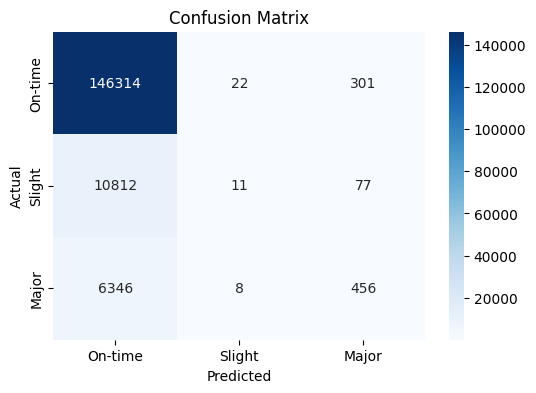

In [ ]:
# STEP 4: Evaluate the classifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred_class = clf_pipeline.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred_class)
print(f"🎯 Accuracy: {acc:.4f}")

# Detailed classification report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_class, digits=3))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On-time','Slight','Major'],
            yticklabels=['On-time','Slight','Major'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [35]:
# STEP 6: Train Balanced XGBoostClassifier

from xgboost import XGBClassifier

# Class weights based on frequency
weights = {
    0: 1,    # On time
    1: 13,   # Slight delay
    2: 20    # Major delay
}

# Convert class labels to weights for training rows
y_train_weights = y_train.map(weights)

xgb_balanced = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.2,
    reg_lambda=2,
    objective='multi:softprob',  # multi-class
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

balanced_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_balanced)
])

print("⏳ Training Balanced XGBoost Classifier...")
balanced_pipeline.fit(X_train, y_train, model__sample_weight=y_train_weights)
print("✅ Training complete!")



⏳ Training Balanced XGBoost Classifier...
✅ Training complete!



🎯 Balanced Accuracy: 0.673836455791709

📊 Balanced Classification Report:
              precision    recall  f1-score   support

           0      0.927     0.714     0.807    146637
           1      0.105     0.331     0.159     10900
           2      0.142     0.357     0.203      6810

    accuracy                          0.674    164347
   macro avg      0.391     0.467     0.390    164347
weighted avg      0.840     0.674     0.739    164347



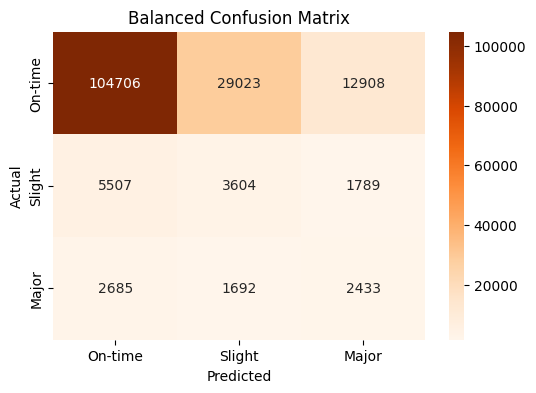

In [37]:
# STEP 7: Evaluate Balanced Model

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred_bal = balanced_pipeline.predict(X_test)

print("\n🎯 Balanced Accuracy:", accuracy_score(y_test, y_pred_bal))

print("\n📊 Balanced Classification Report:")
print(classification_report(y_test, y_pred_bal, digits=3))

cm_bal = confusion_matrix(y_test, y_pred_bal)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_bal,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['On-time','Slight','Major'],
    yticklabels=['On-time','Slight','Major']
)
plt.title("Balanced Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
import joblib
joblib.dump(balanced_pipeline, "delay_classifier.pkl")


In [ ]:
# Show all unique train types
print("Train types:", df['service_type'].unique())

# Group train numbers by train type
train_map = df.groupby('service_type')['service_train_number'].unique()

for t, nums in train_map.items():
    print(f"\n==== {t} ====")
    print(f"Total unique trains: {len(nums)}")
    print(nums[:50])   # show first 50 (avoids too long output)
